# Single factor analysis

In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\data\development_data.csv")

In [3]:
from python_modules.src.outlier_handler import cont_outliers

In [4]:
train = cont_outliers(train)

In [5]:
import pickle

In [6]:
with open(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\pickle\cont_cat.pkl", "rb") as f:
    col_type = pickle.load(f)

In [7]:
col_type

{'continious': ['age',
  'total_orders',
  'total_spend_usd',
  'avg_order_value_usd',
  'days_since_last_purchase',
  'reviews_given',
  'avg_review_score',
  'wishlist_items'],
 'categorical': ['preferred_device',
  'membership_tier',
  'newsletter_subscribed',
  'acquisition_channel',
  'preferred_category',
  'returns_made',
  'preferred_payment_method',
  'country',
  'registration_date',
  'gender']}

In [8]:
def quantile_sorter(p, P):
    for s, q in P:
        if q >= p:
            return s

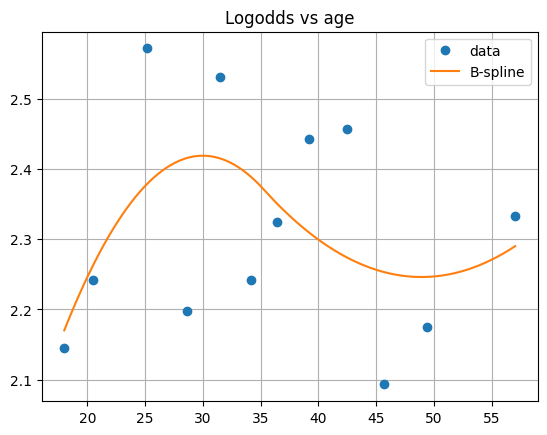

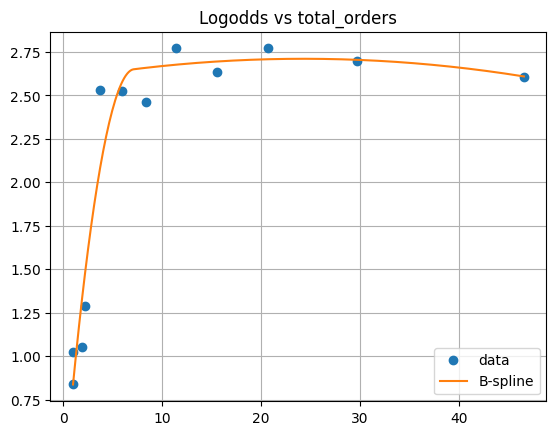

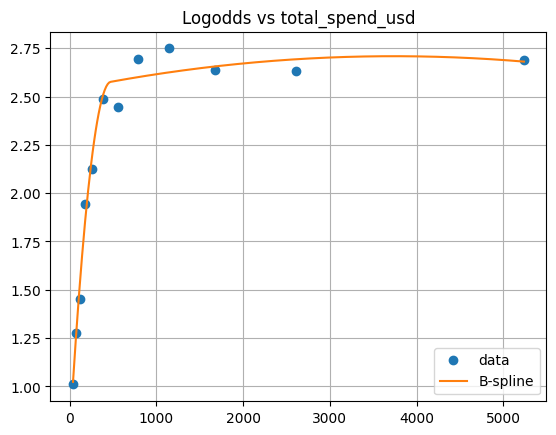

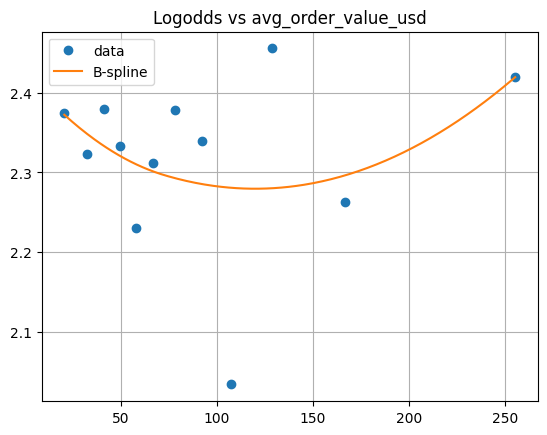

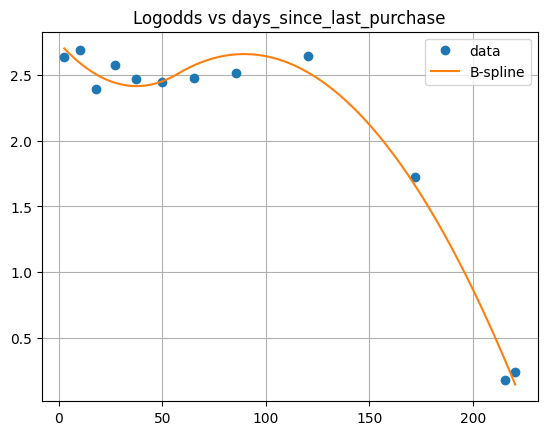

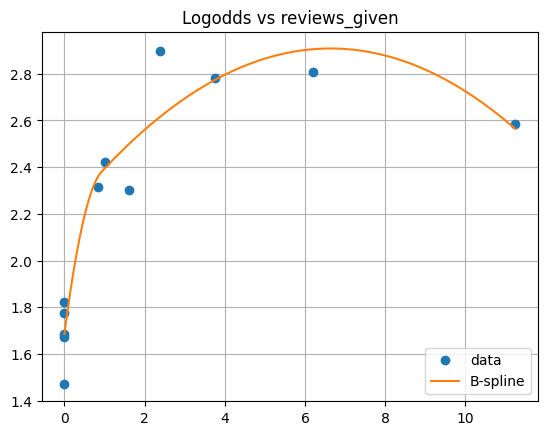

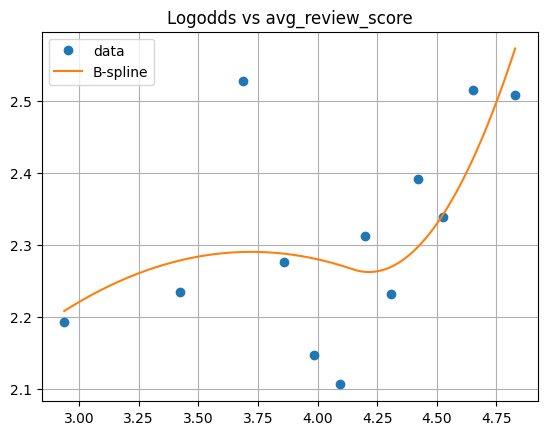

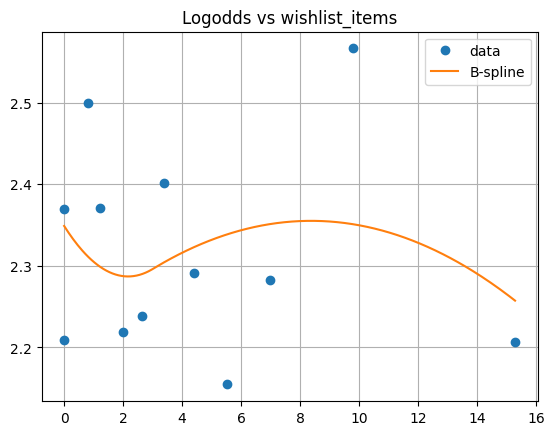

In [9]:
from scipy.interpolate import LSQUnivariateSpline
import matplotlib.pyplot as plt

splines = {}

for var in col_type["continious"]:
    train.sort_values(by = var, ascending=True, inplace=True)
    train["cumsum"] = train["churned"].cumsum()
    train["fractile"] = train["cumsum"]/train["churned"].sum()
    L = np.linspace(0, 1, round(train["churned"].sum()/50))
    L = list(L)
    L.remove(np.float64(0.0))
    L = list(enumerate(L))
    train["group"] = train["fractile"].apply(lambda p: quantile_sorter(p,L))
    agg_data = train.groupby("group").agg({var: "mean", "churned": "mean"})
    agg_data["logodds"] = -np.log(agg_data["churned"]/(1-agg_data["churned"]))
    # Specify the number of interior knots you want
    n_knots = 3
    knots = np.quantile(agg_data[var], np.linspace(0, 1, n_knots))[1:-1]
    spl = LSQUnivariateSpline(agg_data[var], agg_data["logodds"], t=knots, k=2)
    splines[var] = spl
    x_smooth = np.linspace(agg_data[var].min(), agg_data[var].max(), 300)
    plt.figure()
    plt.plot(agg_data[var], agg_data["logodds"], 'o', label='data')
    plt.plot(x_smooth, spl(x_smooth), label='B-spline')
    plt.title(f"Logodds vs {var}")
    plt.grid(True)
    plt.legend()

The variables:

* reviews_given
* days_since_last_purchase
* total_usd_spend
* total_orders

seems to have a reasonable relationship between -logodds of the churnrate and the variables that can be smoothed out.

In [10]:
L = ["wishlist_items",
     "avg_review_score",
     "avg_order_value_usd",
     "age"]

for s in L:
    del splines[s]

In [11]:
with open(r"C:\Users\niels\OneDrive\Dokumenter\Churn modelling\Churn-modelling\pickle\logodds_splines.pkl", "wb") as file:
    pickle.dump(splines, file)

In [12]:
for var in splines.keys():
    train["logodds_" + var] = splines[var](train[var])

In [13]:
from optbinning import OptimalBinning

In [14]:
binning = {}
woe = {}

for s in L:
    binning[s] = OptimalBinning(name=s, dtype="numerical", solver="cp")
    binning[s].fit(train[s], train["churned"])
    woe[s] = binning[s].binning_table.build()
    train["WoE_" + s] = binning[s].transform(train[s], metric="indices")
    train["WoE_" + s] = train["WoE_" + s].map(woe[s]["WoE"]).astype(float)

for s in col_type["categorical"]:
    binning[s] = OptimalBinning(name=s, dtype="categorical", solver="cp")
    binning[s].fit(train[s], train["churned"])
    woe[s] = binning[s].binning_table.build()
    train["WoE_" + s] = binning[s].transform(train[s], metric="indices")
    train["WoE_" + s] = train["WoE_" + s].map(woe[s]["WoE"]).astype(float)


In [15]:
import statsmodels.api as sm

In [18]:
from sklearn.metrics import roc_auc_score

def bidirectional_stepwise_somers_d(X, y, initial_features=None, p_threshold=0.05, somers_d_min_gain=0.001):
    """
    Forward-backward stepwise selection using p-values AND Somer's D (2*AUC - 1)
    
    Parameters:
    - X: Features dataframe
    - y: Target variable
    - initial_features: Starting features (default: all)
    - p_threshold: p-value threshold for significance (default: 0.05)
    - somers_d_min_gain: minimum Somer's D improvement to add feature (default: 0.001)
    """
    if initial_features is None:
        initial_features = list(X.columns)
    
    current_features = initial_features.copy()
    improved = True
    iteration = 0
    
    def calculate_somers_d(features):
        """Calculate Somer's D for given features"""
        if len(features) == 0:
            return 0
        model = sm.Logit(y, sm.add_constant(X[features])).fit(disp=0)
        pred = model.predict(sm.add_constant(X[features]))
        return 2 * roc_auc_score(y, pred) - 1
    
    # Calculate initial Somer's D
    current_somers_d = calculate_somers_d(current_features)
    print(f"Starting Somer's D: {current_somers_d:.4f} with features: {current_features}\n")
    
    while improved:
        iteration += 1
        improved = False
        
        # FORWARD STEP: Try adding features not yet in model
        remaining_features = [f for f in X.columns if f not in current_features]
        best_feature = None
        best_somers_d = current_somers_d
        best_pvalue = 1.0
        
        for feature in remaining_features:
            test_features = current_features + [feature]
            model = sm.Logit(y, sm.add_constant(X[test_features])).fit(disp=0)
            p_val = model.pvalues[feature]
            
            # Only consider features with p < threshold
            if p_val < p_threshold:
                test_somers_d = calculate_somers_d(test_features)
                
                # Add if Somer's D improves
                if test_somers_d > best_somers_d + somers_d_min_gain:
                    best_somers_d = test_somers_d
                    best_feature = feature
                    best_pvalue = p_val
        
        # Add feature if it improves Somer's D
        if best_feature:
            current_features.append(best_feature)
            current_somers_d = best_somers_d
            improved = True
            print(f"Iteration {iteration}: Added '{best_feature}' (p={best_pvalue:.4f}, Somer's D={current_somers_d:.4f})")
        
        # BACKWARD STEP: Try removing features from model
        if len(current_features) > 1 and not improved:  # Only backward if forward didn't add
            model = sm.Logit(y, sm.add_constant(X[current_features])).fit(disp=0)
            worst_feature = None
            max_pvalue = 0
            
            for feature in current_features:
                p_val = model.pvalues[feature]
                if p_val > max_pvalue:
                    max_pvalue = p_val
                    worst_feature = feature
            
            # Remove if not significant
            if worst_feature and max_pvalue > p_threshold:
                test_features = [f for f in current_features if f != worst_feature]
                test_somers_d = calculate_somers_d(test_features)
                
                # Only remove if Somer's D doesn't decrease too much
                if test_somers_d >= current_somers_d - somers_d_min_gain:
                    current_features = test_features
                    current_somers_d = test_somers_d
                    improved = True
                    print(f"Iteration {iteration}: Removed '{worst_feature}' (p={max_pvalue:.4f}, Somer's D={current_somers_d:.4f})")
    
    print(f"\nFinal features: {current_features}")
    print(f"Final Somer's D: {current_somers_d:.4f}")
    return current_features

In [19]:
features = [s for s in train.columns if ('logodds_' in s or 'WoE_' in s) and (('registration_date' in s) == False)]
X = train[features].copy()
y = train["churned"]

In [20]:
bidirectional_stepwise_somers_d(X=X, y=y)

Starting Somer's D: 0.5083 with features: ['logodds_total_orders', 'logodds_total_spend_usd', 'logodds_days_since_last_purchase', 'logodds_reviews_given', 'WoE_wishlist_items', 'WoE_avg_review_score', 'WoE_avg_order_value_usd', 'WoE_age', 'WoE_preferred_device', 'WoE_membership_tier', 'WoE_newsletter_subscribed', 'WoE_acquisition_channel', 'WoE_preferred_category', 'WoE_returns_made', 'WoE_preferred_payment_method', 'WoE_country', 'WoE_gender']

Iteration 1: Removed 'logodds_total_spend_usd' (p=0.8144, Somer's D=0.5081)
Iteration 2: Removed 'WoE_gender' (p=0.7026, Somer's D=0.5077)
Iteration 3: Removed 'logodds_reviews_given' (p=0.4327, Somer's D=0.5075)
Iteration 4: Removed 'WoE_newsletter_subscribed' (p=0.3300, Somer's D=0.5068)
Iteration 5: Removed 'WoE_preferred_payment_method' (p=0.1129, Somer's D=0.5079)

Final features: ['logodds_total_orders', 'logodds_days_since_last_purchase', 'WoE_wishlist_items', 'WoE_avg_review_score', 'WoE_avg_order_value_usd', 'WoE_age', 'WoE_preferred_d

['logodds_total_orders',
 'logodds_days_since_last_purchase',
 'WoE_wishlist_items',
 'WoE_avg_review_score',
 'WoE_avg_order_value_usd',
 'WoE_age',
 'WoE_preferred_device',
 'WoE_membership_tier',
 'WoE_acquisition_channel',
 'WoE_preferred_category',
 'WoE_returns_made',
 'WoE_country']

In [50]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np

def fit_logodds_transforms(data, target_col, splines_dict=None):
    """Fit logodds splines on data and return transformations"""
    from scipy.interpolate import LSQUnivariateSpline
    
    data_copy = data.copy()
    fitted_splines = {}
    
    for var in col_type["continious"]:
        data_copy.sort_values(by=var, ascending=True, inplace=True)
        data_copy["cumsum"] = data_copy[target_col].cumsum()
        data_copy["fractile"] = data_copy["cumsum"] / data_copy[target_col].sum()
        
        L = np.linspace(0, 1, round(data_copy[target_col].sum() / 50))
        L = list(L)
        L.remove(np.float64(0.0))
        L = list(enumerate(L))
        
        data_copy["group"] = data_copy["fractile"].apply(lambda p: quantile_sorter(p, L))
        agg_data = data_copy.groupby("group").agg({var: "mean", target_col: "mean"})
        agg_data["logodds"] = -np.log(agg_data[target_col] / (1 - agg_data[target_col]))
        
        n_knots = 3
        knots = np.quantile(agg_data[var], np.linspace(0, 1, n_knots))[1:-1]
        spl = LSQUnivariateSpline(agg_data[var], agg_data["logodds"], t=knots, k=2)
        fitted_splines[var] = spl
    
    return fitted_splines


def apply_logodds_transforms(data, splines_dict):
    """Apply fitted logodds splines to data"""
    data_transformed = data.copy()
    for var, spl in splines_dict.items():
        data_transformed["logodds_" + var] = spl(data_transformed[var])
    return data_transformed


def fit_woe_transforms(data, target_col, woe_dict=None):
    """Fit WoE binning on data and return transformations"""
    fitted_binning = {}
    
    # Continuous variables
    for s in ["wishlist_items", "avg_review_score", "avg_order_value_usd", "age"]:
        if s in data.columns:
            binning_obj = OptimalBinning(name=s, dtype="numerical", solver="cp")
            binning_obj.fit(data[s], data[target_col])
            fitted_binning[s] = binning_obj
    
    # Categorical variables
    for s in col_type["categorical"]:
        if s in data.columns:
            binning_obj = OptimalBinning(name=s, dtype="categorical", solver="cp")
            binning_obj.fit(data[s], data[target_col])
            fitted_binning[s] = binning_obj
    
    return fitted_binning

def apply_woe_transforms(data, binning_dict):
    """Apply fitted WoE binning to data, handling out-of-sample values"""
    data_transformed = data.copy()
    for var, binning_obj in binning_dict.items():
        # # DIAGNOSTIC: Check for NaN in original variable BEFORE transformation
        # original_nan_count = data_transformed[var].isna().sum()
        
        indices = binning_obj.transform(data_transformed[var], metric="indices")
        
        # # DIAGNOSTIC: Check for NaN in indices AFTER transform
        # indices_nan_count = sum(pd.isna(indices)) if isinstance(indices, (list, np.ndarray)) else indices.isna().sum()
        
        woe_table = binning_obj.binning_table.build()
        
        # print(f"\n{'='*60}")
        # print(f"WoE Transform: {var}")
        # print(f"{'='*60}")
        # print(f"WoE Table:")
        # print(woe_table)
        # print(f"\nWoE Dictionary keys: {list(woe_table['WoE'].keys())}")
        # print(f"WoE Dictionary values: {list(woe_table['WoE'])}")
        
        # Map indices to WoE values - PRESERVE INDEX!
        woe_series = pd.Series(indices, index=data_transformed.index).map(woe_table["WoE"]).astype(float)
        
        # print(f"\nIndices sample (first 20): {list(indices[:20])}")
        # print(f"Original variable NaN: {original_nan_count}")
        # print(f"Indices NaN after transform: {indices_nan_count}")
        # print(f"WoE series NaN BEFORE fill: {sum(np.isnan(woe_series))}")
        
        # Handle missing WoE values (out-of-sample observations)
        missing_mask = woe_series.isna()
        if missing_mask.any():
            # print(f"Found {missing_mask.sum()} NaN values to fill")
            # Show which indices are missing from the woe_table
            missing_indices = pd.Series(indices, index=data_transformed.index)[missing_mask].unique()
            # print(f"Missing indices in woe_table: {missing_indices}")
            
            # Fill with the mean WoE from the training binning table
            woe_values = woe_table["WoE"][:-1].copy().astype(float)
            # print(f"WoE values for mean calculation: {woe_values}")
            mean_woe = woe_values.mean()
            # print(f"Mean WoE (before fill): {mean_woe}")
            
            woe_series[missing_mask] = mean_woe
            # print(f"WoE series NaN AFTER fill: {sum(np.isnan(woe_series))}")
            # print(f"  Warning: {missing_mask.sum()} out-of-sample values for '{var}' filled with mean WoE ({mean_woe:.4f})")
        # else:
            # print("✓ No NaN values to fill")
        
        data_transformed["WoE_" + var] = woe_series
        # print(f"Final WoE column NaN count: {data_transformed['WoE_' + var].isna().sum()}")
    
    return data_transformed


def kfold_cross_validation_features(train, target_col, selected_features, n_splits=5):
    """
    K-fold cross-validation for pre-selected features with per-fold logodds and WoE recalculation
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_results = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(train)):
        print(f"\n{'='*60}")
        print(f"FOLD {fold_idx + 1}/{n_splits}")
        print(f"{'='*60}")

        # Split data
        train_fold = train.iloc[train_idx].copy()
        test_fold = train.iloc[test_idx].copy()

        # Step 1: Fit logodds splines on training fold
        print("Fitting logodds splines...")
        fitted_splines = fit_logodds_transforms(train_fold, target_col)
        
        # Apply logodds to both folds
        train_fold = apply_logodds_transforms(train_fold, fitted_splines)
        test_fold = apply_logodds_transforms(test_fold, fitted_splines)
        
        # Step 2: Fit WoE binning on training fold
        print("Fitting WoE binning...")
        fitted_binning = fit_woe_transforms(train_fold, target_col)
        
        # Apply WoE to both folds
        train_fold = apply_woe_transforms(train_fold, fitted_binning)
        test_fold = apply_woe_transforms(test_fold, fitted_binning)
        
        # Step 3: Extract selected features from test fold
        X_test = test_fold[selected_features].copy()
        y_test = test_fold[target_col]
        
        # Step 4: Evaluate on test fold
        print("Fitting the model...")
        model_test = sm.Logit(y_test, sm.add_constant(X_test)).fit(disp=0)
        pred_test = model_test.predict(sm.add_constant(X_test))
        test_somers_d = 2 * roc_auc_score(y_test, pred_test) - 1
        
        print(f"Fold {fold_idx + 1} - Test Somer's D: {test_somers_d:.4f}")
        
        fold_results.append({
            'fold': fold_idx + 1,
            'test_somers_d': test_somers_d
        })
    
    # Summary statistics
    print(f"\n{'='*60}")
    print(f"CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    
    avg_somers_d = np.mean([r['test_somers_d'] for r in fold_results])
    std_somers_d = np.std([r['test_somers_d'] for r in fold_results])
    
    print(f"Mean Somer's D: {avg_somers_d:.4f} (+/- {std_somers_d:.4f})")
    print(f"Features validated: {selected_features}")
    
    return fold_results


# Run with your previously selected features
selected_features = bidirectional_stepwise_somers_d(X=X, y=y)

fold_results = kfold_cross_validation_features(
    train=train[["churned"] + col_type["categorical"] + col_type["continious"]],
    target_col="churned",
    selected_features=selected_features,
    n_splits=5
)

Starting Somer's D: 0.5083 with features: ['logodds_total_orders', 'logodds_total_spend_usd', 'logodds_days_since_last_purchase', 'logodds_reviews_given', 'WoE_wishlist_items', 'WoE_avg_review_score', 'WoE_avg_order_value_usd', 'WoE_age', 'WoE_preferred_device', 'WoE_membership_tier', 'WoE_newsletter_subscribed', 'WoE_acquisition_channel', 'WoE_preferred_category', 'WoE_returns_made', 'WoE_preferred_payment_method', 'WoE_country', 'WoE_gender']

Iteration 1: Removed 'logodds_total_spend_usd' (p=0.8144, Somer's D=0.5081)
Iteration 2: Removed 'WoE_gender' (p=0.7026, Somer's D=0.5077)
Iteration 3: Removed 'logodds_reviews_given' (p=0.4327, Somer's D=0.5075)
Iteration 4: Removed 'WoE_newsletter_subscribed' (p=0.3300, Somer's D=0.5068)
Iteration 5: Removed 'WoE_preferred_payment_method' (p=0.1129, Somer's D=0.5079)

Final features: ['logodds_total_orders', 'logodds_days_since_last_purchase', 'WoE_wishlist_items', 'WoE_avg_review_score', 'WoE_avg_order_value_usd', 'WoE_age', 'WoE_preferred_d